# Exploratory Neural and Hybrid Modeling

This notebook integrates descriptor MLP analysis (Notebook 5), multi-MLP analysis (Notebook 6-3), and neural/tree/hybrid exploration (Notebook 7). It is exploratory and does not select a final project model.

> **Notebook 7: Exploratory reused holdout.** The same 80/20 holdout was reused for model comparison, checkpoint selection, and hybrid comparison. It is not independent final evaluation. Historical NN+Tree5 ROC-AUC 0.738666 is an **Exploratory reused holdout** value only.

The current accepted cohort is the frozen 1,198-row `DILIst_Final.csv`; 1,197 structures parse, with DILIST_ID 397 excluded. Historical 1,202-row results remain reference-only.


## 1. Purpose and boundaries

- Recompute the audited Notebook 5 descriptor RF/MLP five-fold CV and pooled OOF analysis on the current cohort.
- Present Notebook 6-3 combined-feature MLP results from its accepted audit output; do not rerun the computationally intensive ensemble.
- Present audited Notebook 7 tree reruns and historical references. PyTorch neural reruns were unavailable in the audited environment; do not substitute a framework or infer scores.
- No tuning, final model selection, independent holdout creation, or final evaluation.

CV, pooled OOF, historical reference, and Notebook 7 **Exploratory reused holdout** are separate result types.


## 2. Frozen cohort and provenance

Expected SHA-256: `4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7`. Expected raw counts are 463 / 735; after excluding malformed DILIST_ID 397, 1,197 valid structures remain (462 / 735).

In [1]:
from pathlib import Path
import hashlib, json, warnings, importlib.util
import numpy as np, pandas as pd, sklearn, rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors

EXPECTED='4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7'
PROTECTED={
 '01_dataset_construction.ipynb':'28b6c13409d1fc639ae17c6c0bca742a883cff29cc0de5acd3838d158f8da865',
 '02_morgan_fingerprint_analysis.ipynb':'55e2ab69669f62f4bdab82e7d938c3b13e27e8948ed9a2028e06a5bb84971943',
 '03_rdkit_descriptor_modeling.ipynb':'4752f555a27aaf4b3ac766c7baccc1d1fb9cbc9fc630b31ee1686a46ca6134db',
 '04_feature_and_model_comparison.ipynb':'85b25a37aec9fe87e3f838c895fa5ec3ea82dccd87a69ecc353020aeb8c9659e',
 '6-3. 다중 Neural Network 성능 개선.ipynb':'cdd610b49e5f929ca532fe2de516eaa44176b55b13bfb6b9de7f83b5bea2eae6',
 '7. 마지막이야....ipynb':'141183c9e02c9403fb13200adb3ac7084d76c3cb87e691f6e129a3e0e29e936d',
 '7. 마지막이야_1.ipynb':'91bb5ed8568b3e82fac557172d227f74c8ffb5c1c38d439ccd2407aa7d613ad5'}
def sha(p):
 h=hashlib.sha256()
 with open(p,'rb') as f:
  for b in iter(lambda:f.read(1<<20),b''): h.update(b)
 return h.hexdigest()
ROOT=Path.cwd().resolve()
while ROOT!=ROOT.parent and not (ROOT/'DILIst_Final.csv').exists(): ROOT=ROOT.parent
DATA=ROOT/'DILIst_Final.csv'
assert DATA.exists() and sha(DATA)==EXPECTED
raw=pd.read_csv(DATA); target='DILIst Classification '
assert raw.shape==(1198,5) and target in raw and raw['DILIST_ID'].is_unique
assert raw[target].value_counts().sort_index().to_dict()=={0:463,1:735}
assert raw['SMILES'].isna().sum()==0
valid=[]; invalid=[]
for _,r in raw.iterrows():
 m=Chem.MolFromSmiles(str(r['SMILES']))
 if m is None: invalid.append({'DILIST_ID':int(r.DILIST_ID),'CompoundName':r.CompoundName,'SMILES':r.SMILES})
 else: valid.append(r)
valid_df=pd.DataFrame(valid).reset_index(drop=True)
assert len(valid_df)==1197 and [x['DILIST_ID'] for x in invalid]==[397]
assert valid_df[target].value_counts().sort_index().to_dict()=={0:462,1:735}
print({'file':DATA.name,'sha256':sha(DATA),'shape':raw.shape,'columns':raw.columns.tolist(),
       'target':target,'raw_classes':raw[target].value_counts().sort_index().to_dict(),
       'valid_structures':len(valid_df),'valid_classes':valid_df[target].value_counts().sort_index().to_dict(),
       'invalid':invalid,'pandas':pd.__version__,'sklearn':sklearn.__version__,'RDKit':rdkit.__version__})


{'file': 'DILIst_Final.csv', 'sha256': '4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7', 'shape': (1198, 5), 'columns': ['DILIST_ID', 'CompoundName', 'DILIst Classification ', 'Routs of Administration ', 'SMILES'], 'target': 'DILIst Classification ', 'raw_classes': {0: 463, 1: 735}, 'valid_structures': 1197, 'valid_classes': {0: 462, 1: 735}, 'invalid': [{'DILIST_ID': 397, 'CompoundName': 'nitroprusside', 'SMILES': '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N'}], 'pandas': '3.0.2', 'sklearn': '1.8.0', 'RDKit': '2026.03.1'}


[00:38:38] WARNING: not removing hydrogen atom without neighbors
[00:38:38] SMILES Parse Error: syntax error while parsing: [Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N
[00:38:38] SMILES Parse Error: check for mistakes around position 6:
[00:38:38] [Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]
[00:38:38] ~~~~~^
[00:38:38] SMILES Parse Error: Failed parsing SMILES '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N' for input: '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N'
[00:38:38] WARNING: not removing hydrogen atom without neighbors
[00:38:38] WARNING: not removing hydrogen atom without neighbors


## 3. Notebook 5 descriptor models: legacy workflow reproduction

The audited workflow generated and cleaned descriptor columns before CV. That global descriptor cleanup is preserved (it is not moved into folds). Median imputation is inside both model pipelines; MLP scaling is inside its pipeline. CV and pooled OOF are not independent test performance.

Descriptors use `rdkit.Chem.Descriptors.descList`. The accepted cohort yields 217 retained descriptors. Infinite values and values with absolute magnitude above 1e12 are set to NaN; the audit records 77 such extreme cells, no descriptor-function exceptions, and no all-NaN columns. ID 397 is explicitly excluded as an invalid structure.


In [2]:
descriptor_names=[n for n,_ in Descriptors.descList]
desc_rows=[]; ids=[]; exceptions=[]
for _,r in valid_df.iterrows():
 mol=Chem.MolFromSmiles(str(r['SMILES'])); vals={}
 for name,fn in Descriptors.descList:
  try: vals[name]=fn(mol)
  except Exception as e: vals[name]=np.nan; exceptions.append((int(r.DILIST_ID),name,repr(e)))
 desc_rows.append(vals); ids.append(int(r.DILIST_ID))
desc=pd.DataFrame(desc_rows,index=ids,columns=descriptor_names).apply(lambda c:pd.to_numeric(c,errors='coerce'))
inf_count=int(np.isinf(desc.to_numpy(float)).sum())
extreme_mask=np.abs(desc.to_numpy(float))>1e12
extreme_count=int(extreme_mask.sum())
desc=desc.replace([np.inf,-np.inf],np.nan).mask(lambda z:z.abs()>1e12,np.nan)
all_nan=desc.columns[desc.isna().all()].tolist(); desc=desc.drop(columns=all_nan)
assert len(descriptor_names)==217 and desc.shape==(1197,217)
assert not exceptions and inf_count==0 and extreme_count==77 and all_nan==[]
assert int(np.isinf(desc.to_numpy(float)).sum())==0
print({'descriptor_count_generated':len(descriptor_names),'retained':desc.shape[1],
       'exceptions':len(exceptions),'infinite_cells':inf_count,'extreme_cells_set_nan':extreme_count,
       'all_nan_columns_removed':len(all_nan),'remaining_missing_cells':int(desc.isna().sum().sum())})
display(pd.DataFrame({'descriptor':desc.columns,'missing':desc.isna().sum().values}).head(12))


[00:38:42] WARNING: not removing hydrogen atom without neighbors
[00:38:42] WARNING: not removing hydrogen atom without neighbors


[00:39:29] WARNING: not removing hydrogen atom without neighbors
[00:39:29] WARNING: not removing hydrogen atom without neighbors
[00:39:29] WARNING: not removing hydrogen atom without neighbors
[00:39:29] WARNING: not removing hydrogen atom without neighbors


{'descriptor_count_generated': 217, 'retained': 217, 'exceptions': 0, 'infinite_cells': 0, 'extreme_cells_set_nan': 77, 'all_nan_columns_removed': 0, 'remaining_missing_cells': 337}


,descriptor,missing
0,MaxAbsEStateIndex,0
1,MaxEStateIndex,0
2,MinAbsEStateIndex,0
3,MinEStateIndex,0
4,qed,0
5,SPS,0
6,MolWt,0
7,HeavyAtomMolWt,0
8,ExactMolWt,0
9,NumValenceElectrons,0


### Model configurations and CV / pooled OOF

**Random Forest:** `n_estimators=300`, `max_depth=10`, `min_samples_split=5`, `class_weight="balanced"`, `random_state=42`.

**MLP classifier:** `(256,128)`, ReLU, Adam, alpha .001, batch 32, learning rate .001, max_iter 500, early stopping, validation fraction .15, no-change patience 30, seed 42. This is `MLPClassifier`, as in the audited Notebook 5.

Evaluation: five-fold `StratifiedKFold(shuffle=True, random_state=42)`. Fold metrics are mean and population SD across folds, matching the audited result calculation. Pooled OOF metrics are computed separately from fold-held predictions/probabilities, with threshold 0.5 for F1.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score,make_scorer
from sklearn.model_selection import StratifiedKFold,cross_validate,cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X=desc.to_numpy(float)
y=valid_df.set_index('DILIST_ID').loc[desc.index,target].astype(int).to_numpy()
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring={'accuracy':'accuracy','roc_auc':'roc_auc','f1':make_scorer(f1_score)}
models={
 'Random Forest (Notebook 5 descriptors)':Pipeline([('imputer',SimpleImputer(strategy='median')),
  ('model',RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_split=5,
   class_weight='balanced',random_state=42,n_jobs=-1))]),
 'MLP (Notebook 5 descriptors)':Pipeline([('imputer',SimpleImputer(strategy='median')),
  ('scaler',StandardScaler()),('model',MLPClassifier(hidden_layer_sizes=(256,128),activation='relu',solver='adam',
   alpha=.001,batch_size=32,learning_rate_init=.001,max_iter=500,early_stopping=True,
   validation_fraction=.15,n_iter_no_change=30,random_state=42))])}
fold_rows=[]; summary_rows=[]
for name,model in models.items():
 print('Evaluating',name)
 scores=cross_validate(model,X,y,cv=cv,scoring=scoring,n_jobs=1,error_score='raise')
 probs=cross_val_predict(model,X,y,cv=cv,method='predict_proba',n_jobs=1)[:,1]
 pred=(probs>=.5).astype(int)
 rec={'model':name,'n_samples':len(y),'n_features':X.shape[1]}
 for metric in ['accuracy','roc_auc','f1']:
  rec[f'{metric}_mean']=float(np.mean(scores['test_'+metric]))
  rec[f'{metric}_std']=float(np.std(scores['test_'+metric],ddof=0))
  for k,val in enumerate(scores['test_'+metric],1): fold_rows.append({'model':name,'fold':k,'metric':metric,'value':float(val)})
 rec.update({'oof_accuracy':float(accuracy_score(y,pred)),'oof_roc_auc':float(roc_auc_score(y,probs)),
             'oof_f1':float(f1_score(y,pred))})
 summary_rows.append(rec)
summary=pd.DataFrame(summary_rows); fold_table=pd.DataFrame(fold_rows)
display(summary)
display(fold_table)


Evaluating Random Forest (Notebook 5 descriptors)


Evaluating MLP (Notebook 5 descriptors)


,model,n_samples,n_features,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,oof_accuracy,oof_roc_auc,oof_f1
0,Random Forest (Notebook 5 descriptors),1197,217,0.677493,0.023981,0.704612,0.027857,0.756947,0.020552,0.677527,0.704557,0.757233
1,MLP (Notebook 5 descriptors),1197,217,0.642434,0.006531,0.658267,0.020635,0.733120,0.014326,0.642439,0.657736,0.733831


,model,fold,metric,value
0,Random Forest (Notebook 5 descriptors),1,accuracy,0.716667
1,Random Forest (Notebook 5 descriptors),2,accuracy,0.679167
2,Random Forest (Notebook 5 descriptors),3,accuracy,0.648536
3,Random Forest (Notebook 5 descriptors),4,accuracy,0.656904
4,Random Forest (Notebook 5 descriptors),5,accuracy,0.686192
5,Random Forest (Notebook 5 descriptors),1,roc_auc,0.711506
6,Random Forest (Notebook 5 descriptors),2,roc_auc,0.741935
7,Random Forest (Notebook 5 descriptors),3,roc_auc,0.675244
8,Random Forest (Notebook 5 descriptors),4,roc_auc,0.670105
9,Random Forest (Notebook 5 descriptors),5,roc_auc,0.724268


### Compare with accepted Notebook 5 current reproduction

The accepted audit values are references, not hard-coded replacement estimates. This comparison reports fresh-minus-audited differences. Historical Notebook 5 used 1,202 input rows / 1,201 valid structures; its source file is unavailable for row-level verification. Historical MLP CV ROC-AUC (.6748) and pooled OOF ROC-AUC (.6619) differ by about .012889; cause not established.


In [4]:
legacy5=pd.read_csv(ROOT/'results/legacy_notebook5_reproduction.csv')
legacy_names={'Random Forest (Notebook 5 descriptors)':'RandomForest (RDKit descriptors)',
              'MLP (Notebook 5 descriptors)':'Neural Network MLP (RDKit descriptors)'}
comparison=summary.copy(); comparison['legacy_model']=comparison.model.map(legacy_names)
for col in ['cv_accuracy_mean','cv_accuracy_std','cv_roc_auc_mean','cv_roc_auc_std','cv_f1_mean','cv_f1_std','oof_accuracy','oof_roc_auc','oof_f1']:
 comparison['audited_'+col]=comparison.legacy_model.map(legacy5.set_index('model')[col])
 current_col=col.replace('cv_','',1) if col.startswith('cv_') else col
 comparison['difference_'+col]=comparison[current_col]-comparison['audited_'+col]
display(comparison)

tables=ROOT/'results'/'tables'; tables.mkdir(parents=True,exist_ok=True)
out= tables/'mlp_current_cv_oof.csv'; assert not out.exists(),out
rows=[]
for _,r in summary.iterrows():
 for ev,prefix in [('5-fold CV','cv'),('Pooled OOF','oof')]:
  rows.append({'model':r.model,'evaluation_type':ev,
   'accuracy':r.accuracy_mean if prefix=='cv' else r.oof_accuracy,
   'roc_auc':r.roc_auc_mean if prefix=='cv' else r.oof_roc_auc,
   'f1':r.f1_mean if prefix=='cv' else r.oof_f1,
   'accuracy_std':r.accuracy_std if prefix=='cv' else np.nan,
   'roc_auc_std':r.roc_auc_std if prefix=='cv' else np.nan,
   'f1_std':r.f1_std if prefix=='cv' else np.nan})
pd.DataFrame(rows).to_csv(out,index=False)
fold_out=tables/'descriptor_rf_mlp_cv_fold_metrics.csv'; assert not fold_out.exists(),fold_out
fold_table.to_csv(fold_out,index=False)
display(pd.DataFrame(rows)); print('Saved',out,fold_out)


,model,n_samples,n_features,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,oof_accuracy,...,audited_cv_f1_mean,difference_cv_f1_mean,audited_cv_f1_std,difference_cv_f1_std,audited_oof_accuracy,difference_oof_accuracy,audited_oof_roc_auc,difference_oof_roc_auc,audited_oof_f1,difference_oof_f1
0,Random Forest (Notebook 5 descriptors),1197,217,0.677493,0.023981,0.704612,0.027857,0.756947,0.020552,0.677527,...,0.756947,0.0,0.020552,1.387779e-17,0.677527,0.0,0.704557,0.0,0.757233,0.0
1,MLP (Notebook 5 descriptors),1197,217,0.642434,0.006531,0.658267,0.020635,0.733120,0.014326,0.642439,...,0.733120,0.0,0.014326,6.938894e-18,0.642439,0.0,0.657736,0.0,0.733831,0.0


,model,evaluation_type,accuracy,roc_auc,f1,accuracy_std,roc_auc_std,f1_std
0,Random Forest (Notebook 5 descriptors),5-fold CV,0.677493,0.704612,0.756947,0.023981,0.027857,0.020552
1,Random Forest (Notebook 5 descriptors),Pooled OOF,0.677527,0.704557,0.757233,NaN,NaN,NaN
2,MLP (Notebook 5 descriptors),5-fold CV,0.642434,0.658267,0.733120,0.006531,0.020635,0.014326
3,MLP (Notebook 5 descriptors),Pooled OOF,0.642439,0.657736,0.733831,NaN,NaN,NaN


Saved C:\Users\user\Desktop\간독성\results\tables\mlp_current_cv_oof.csv C:\Users\user\Desktop\간독성\results\tables\descriptor_rf_mlp_cv_fold_metrics.csv


### Historical Notebook 5 results (reference only)

The following values are kept separate from the current-cohort table above. Historical Notebook 5 used 1,201 valid structures from an unavailable 1,202-row input file.

| Model | Evaluation | Accuracy | ROC-AUC | F1 |
|---|---|---:|---:|---:|
| Random Forest | 5-fold CV mean | 0.678607 | 0.714336 | 0.757203 |
| Random Forest | Pooled OOF | 0.678601 | 0.713839 | 0.757538 |
| MLP | 5-fold CV mean | 0.661940 | 0.674838 | 0.739388 |
| MLP | Pooled OOF | 0.661948 | 0.661949 | 0.739744 |

Historical MLP CV ROC-AUC and pooled OOF ROC-AUC differ by approximately 0.012889; cause not established. These are historical references, not current-cohort measurements.


## 4. Notebook 6-3 multi-MLP analysis (audit reference)

Notebook 6-3 is distinct from the descriptor-only Notebook 5 MLP. It used Morgan + MACCS + RDKit (**2,432 features**) with median imputation, VarianceThreshold, StandardScaler, and a 5-fold stratified CV/OOF procedure. Current OOF values below are taken from the accepted audit output and are not recomputed here. CV means/SD were not recorded and remain unavailable.

Architectures: MLP 128 `(128,)`, alpha .001, seed 11; MLP 256,128 `(256,128)`, alpha .001, seed 42; MLP 128,64,32 `(128,64,32)`, alpha .003, seed 77. Common settings: ReLU, Adam, batch 32, learning rate .001, max_iter 500, early stopping, validation fraction .15, patience 30. Ensemble = arithmetic mean of OOF probabilities. Historical cohort: 1,202 input / 1,201 usable; current cohort: 1,198 / 1,197.


In [5]:
nb6=pd.read_csv(ROOT/'results/tables/legacy_notebook6_mlp_comparison.csv')
nb6_view=nb6.loc[nb6.variant.eq('Notebook 6-3'),['model','n_samples','n_features','oof_accuracy','oof_roc_auc','oof_f1',
 'historical_oof_accuracy','historical_oof_roc_auc','historical_oof_f1']].copy()
nb6_view['evaluation_type']='Audited pooled OOF reference; 5-fold CV'
display(nb6_view)


,model,n_samples,n_features,oof_accuracy,oof_roc_auc,oof_f1,historical_oof_accuracy,historical_oof_roc_auc,historical_oof_f1,evaluation_type
0,MLP 128,1197,2432,0.619883,0.637670,0.688143,0.633639,0.654308,0.693166,Audited pooled OOF reference; 5-fold CV
1,"MLP 256,128",1197,2432,0.681704,0.679057,0.758708,0.652789,0.658621,0.744015,Audited pooled OOF reference; 5-fold CV
2,"MLP 128,64,32",1197,2432,0.658312,0.679820,0.733203,0.661116,0.672616,0.730998,Audited pooled OOF reference; 5-fold CV
3,Ensemble,1197,2432,0.664996,0.688222,0.738421,0.666944,0.684256,0.738220,Audited pooled OOF reference; 5-fold CV


## 5. Notebook 5 hard-example context

The existing current-cohort hard-example table is read-only. “Error” means pooled OOF class prediction at threshold .5 differs from the label. Accepted counts: RF 386, MLP 428, overlap 288, union 526; historical union 507. These are exploratory OOF errors, not independent evaluation errors, and do not imply biological or mechanistic causes.


In [6]:
hard=pd.read_csv(ROOT/'results/tables/legacy_notebook5_hard_examples.csv')
assert len(hard)==526
hard_summary=pd.DataFrame([
 {'cohort':'Current reconstructed','quantity':'RF OOF errors','count':386},
 {'cohort':'Current reconstructed','quantity':'MLP OOF errors','count':428},
 {'cohort':'Current reconstructed','quantity':'Overlap','count':288},
 {'cohort':'Current reconstructed','quantity':'Union rows','count':len(hard)},
 {'cohort':'Historical reference','quantity':'Union rows','count':507}])
display(hard_summary); display(hard.head())


,cohort,quantity,count
0,Current reconstructed,RF OOF errors,386
1,Current reconstructed,MLP OOF errors,428
2,Current reconstructed,Overlap,288
3,Current reconstructed,Union rows,526
4,Historical reference,Union rows,507


,CompoundName,SMILES,y_true,rf_pred,rf_prob,nn_pred,nn_prob,rf_correct,nn_correct
0,chlorpheniramine,CN(C)CCC(C1=CC=C(C=C1)Cl)C2=CC=CC=N2,0,0,0.287354,1,0.781404,True,False
1,dopamine,C1=CC(=C(C=C1CCN)O)O,0,1,0.734547,1,0.609205,False,False
2,phenobarbital,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2,1,1,0.559113,0,0.495122,True,False
3,rifampin,C[C@H]1/C=C/C=C(\C(=O)NC2=C(C(=C3C(=C2O)C(=C(C...,1,0,0.493396,1,0.626165,False,True
4,aciclovir,C1=NC2=C(N1COCCO)N=C(NC2=O)N,1,1,0.642675,0,0.389118,True,False


## 6. Notebook 7: Exploratory reused holdout

Both original Notebook 7 variants read `DILIst_Final.csv`. Historical usable cohort was 1,201 structures, split 960/241. On the accepted current cohort, the same `train_test_split(test_size=.2, stratify=y, random_state=42)` rule yields 957/240 (holdout class counts 93/147). This is a split-lineage check; models are not retrained here.

**The holdout was reused** for model comparison, neural checkpoint selection, and hybrid comparison. No separate validation set, nested CV, or untouched independent final evaluation existed. Attention/Focal checkpoints were selected by ROC-AUC on this same holdout. All Notebook 7 metrics below are **Exploratory reused holdout**, not independent test performance. Internal stacking CV is model fitting, not external evaluation.


In [7]:
from sklearn.model_selection import train_test_split
y_current=valid_df[target].astype(int).to_numpy()
tr,ho=train_test_split(np.arange(len(y_current)),test_size=.2,stratify=y_current,random_state=42)
holdout_counts=pd.Series(y_current[ho]).value_counts().sort_index().to_dict()
assert (len(tr),len(ho))==(957,240) and holdout_counts=={0:93,1:147}
print({'train':len(tr),'exploratory_reused_holdout':len(ho),'holdout_classes':holdout_counts})


{'train': 957, 'exploratory_reused_holdout': 240, 'holdout_classes': {0: 93, 1: 147}}


### Original model/configuration summary

| Model | Audited configuration summary |
|---|---|
| Attention NN | Attention gate 217→128→217 with ReLU/Sigmoid; classifier 217→256→128→1, BatchNorm/ReLU/Dropout(.3); Adam lr .001, wd .0001, batch 64, max 200 epochs; checkpoint chosen by reused-holdout AUC, patience 25, min delta .0001. |
| Tree Ensemble 3 | Median imputer + stacking RF(400, depth10), ExtraTrees(400, depth10), GradientBoosting(250, lr .05, depth3), balanced/seed42; LogisticRegression meta (`max_iter=1000`), `predict_proba`, inner cv=5. |
| Tree Ensemble 5 | Tree Ensemble 3 plus HistGradientBoosting(max_iter250, lr .05, l2 .1) and AdaBoost(250, lr .05). |
| Focal Loss NN | 217→256→128→1, BatchNorm/ReLU/Dropout(.35); Adam lr .001, wd .0001, batch64, max200; focal gamma2, alpha=training negative fraction; checkpoint selected on reused-holdout AUC. |
| Basic RF | 500 trees, depth10, min split5, balanced, seed42. |
| TreeStack3 | RF(600, depth12, split4), XGBoost(600, depth5, lr .03, subsample/colsample .85, hist), LightGBM(600, lr .03, 31 leaves, subsample/colsample .85); seed42; logistic meta max_iter2000, inner cv5. |
| TreeStack5 | TreeStack3 plus CatBoost(600, depth6, lr .03, Logloss/AUC) and ExtraTrees(600, depth12, split4), seed42. |
| NN+Tree3/5 | Arithmetic mean of Attention NN, Focal Loss NN, and corresponding tree-stack probabilities. Current neural probabilities unavailable. |

Detailed source audit: `docs/NOTEBOOK7_AUDIT.md`. Descriptor generation/coercion/extreme filtering occurred before the split. Neural imputation/scaling were fit on training data. The outer tree-stack imputer was fit on the full training partition before internal stacking folds.


In [8]:
nb7=pd.read_csv(ROOT/'results/legacy_notebook7_reproduction.csv')
metric=['accuracy','roc_auc','pr_auc','f1','recall','precision']
current_rows=[]
for _,r in nb7.iterrows():
 reproduced=str(r.verification_status).startswith('reproduced')
 rec={'model':r.model,'evaluation_type':'Exploratory reused holdout','verification_status':r.verification_status}
 for m in metric: rec[m]=r['current_'+m] if reproduced else np.nan
 current_rows.append(rec)
nb7current=pd.DataFrame(current_rows)
hist=nb7[['model']+[f'historical_{m}' for m in metric]].rename(columns={f'historical_{m}':m for m in metric})
hist['evaluation_type']='Historical reference — Exploratory reused holdout'
for name,frame in [('notebook7_current_reproduction.csv',nb7current),('notebook7_historical_reference.csv',hist)]:
 p=tables/name; assert not p.exists(),p; frame.to_csv(p,index=False)
display(nb7current); display(hist)


,model,evaluation_type,verification_status,accuracy,roc_auc,pr_auc,f1,recall,precision
0,Attention NN,Exploratory reused holdout,not reproduced: PyTorch unavailable; model dep...,NaN,NaN,NaN,NaN,NaN,NaN
1,Tree Ensemble 3,Exploratory reused holdout,reproduced on current cohort,0.675000,0.734694,0.817501,0.731034,0.721088,0.741259
2,Tree Ensemble 5,Exploratory reused holdout,reproduced on current cohort,0.683333,0.746471,0.834078,0.739726,0.734694,0.744828
3,Focal Loss NN,Exploratory reused holdout,not reproduced: PyTorch unavailable; model dep...,NaN,NaN,NaN,NaN,NaN,NaN
4,Basic RandomForest,Exploratory reused holdout,reproduced on current cohort,0.666667,0.733085,0.818890,0.750000,0.816327,0.693642
5,RDKit Tree Stack 3: RF + XGBoost + LGBM,Exploratory reused holdout,reproduced on current cohort,0.687500,0.733231,0.810621,0.745763,0.748299,0.743243
6,RDKit NN Ensemble + RDKit Tree Stack 3: RF + X...,Exploratory reused holdout,not reproduced: PyTorch unavailable; model dep...,NaN,NaN,NaN,NaN,NaN,NaN
7,RDKit Tree Stack 5: RF + XGBoost + LGBM + CatB...,Exploratory reused holdout,reproduced on current cohort,0.695833,0.734474,0.808733,0.747405,0.734694,0.760563
8,RDKit NN Ensemble + RDKit Tree Stack 5: RF + X...,Exploratory reused holdout,not reproduced: PyTorch unavailable; model dep...,NaN,NaN,NaN,NaN,NaN,NaN


,model,accuracy,roc_auc,pr_auc,f1,recall,precision,evaluation_type
0,Attention NN,0.692946,0.731909,0.778816,0.754967,0.770270,0.740260,Historical reference — Exploratory reused holdout
1,Tree Ensemble 3,0.684647,0.713891,0.773104,0.737931,0.722973,0.753521,Historical reference — Exploratory reused holdout
2,Tree Ensemble 5,0.672199,0.717524,0.781341,0.722807,0.695946,0.751825,Historical reference — Exploratory reused holdout
3,Focal Loss NN,0.697095,0.711421,0.732212,0.760656,0.783784,0.738854,Historical reference — Exploratory reused holdout
4,Basic RandomForest,0.680498,0.720939,0.783153,0.761610,0.831081,0.702857,Historical reference — Exploratory reused holdout
5,RDKit Tree Stack 3: RF + XGBoost + LGBM,0.676349,0.715054,0.775309,0.727273,NaN,NaN,Historical reference — Exploratory reused holdout
6,RDKit NN Ensemble + RDKit Tree Stack 3: RF + X...,0.705394,0.738521,0.799719,0.767213,NaN,NaN,Historical reference — Exploratory reused holdout
7,RDKit Tree Stack 5: RF + XGBoost + LGBM + CatB...,0.663900,0.718541,0.772678,0.713781,NaN,NaN,Historical reference — Exploratory reused holdout
8,RDKit NN Ensemble + RDKit Tree Stack 5: RF + X...,0.705394,0.738666,0.800353,0.767213,NaN,NaN,Historical reference — Exploratory reused holdout


Historical NN+Tree5 ROC-AUC was 0.738666, the highest reported historical value among these Notebook 7 exploratory models. It remains **Exploratory reused holdout**, not independent final evaluation. Tree Ensemble 5 had the highest current reproduced ROC-AUC among currently rerunnable tree models (0.746471), descriptively within this reused-holdout comparison only. Neither observation selects the project model.

Current Attention, Focal Loss, NN+Tree3 and NN+Tree5 results were not rerun because PyTorch was unavailable in the audited environment. Historical source rows are unavailable, so causes of differences between historical and current tree metrics are not established.


## 7. Exploratory figures

Notebook 7 figures are separated by cohort and labeled **Exploratory reused holdout**; neither is independent final evaluation.


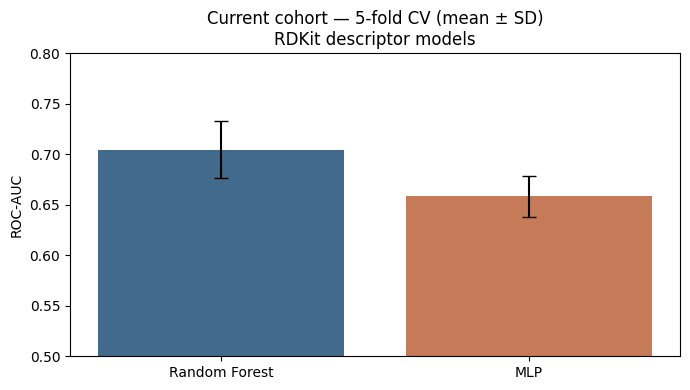

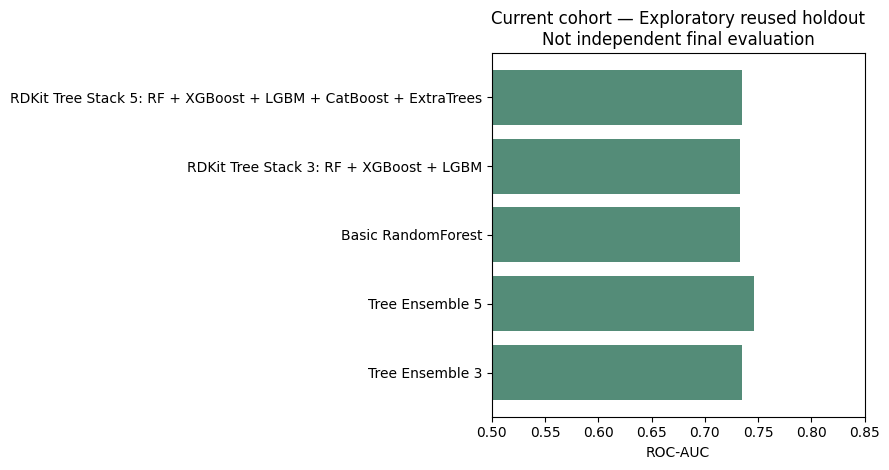

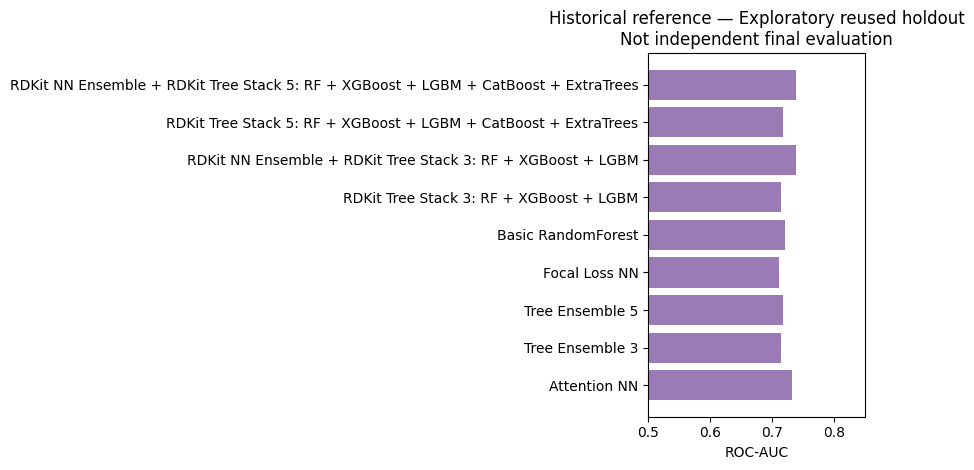

In [9]:
import matplotlib.pyplot as plt
figdir=ROOT/'results/figures'; figdir.mkdir(parents=True,exist_ok=True)
# Current Notebook 5 descriptor CV AUC.
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['Random Forest','MLP'],summary.roc_auc_mean,yerr=summary.roc_auc_std,capsize=5,color=['#426A8C','#C57B57'])
ax.set_ylabel('ROC-AUC'); ax.set_title('Current cohort — 5-fold CV (mean ± SD)\nRDKit descriptor models'); ax.set_ylim(.5,.8)
fig.tight_layout(); fig.savefig(figdir/'neural_current_cv_auc.png',dpi=180); plt.show()
# Current rerunnable Notebook 7 tree models only.
curplot=nb7current.dropna(subset=['roc_auc'])
fig,ax=plt.subplots(figsize=(9,4.8)); ax.barh(curplot.model,curplot.roc_auc,color='#548C78')
ax.set_xlabel('ROC-AUC'); ax.set_title('Current cohort — Exploratory reused holdout\nNot independent final evaluation'); ax.set_xlim(.5,.85)
fig.tight_layout(); fig.savefig(figdir/'notebook7_current_reused_holdout_auc.png',dpi=180); plt.show()
# Historical Notebook 7 references separate from current.
hplot=hist.dropna(subset=['roc_auc'])
fig,ax=plt.subplots(figsize=(9,4.8)); ax.barh(hplot.model,hplot.roc_auc,color='#9A7BB5')
ax.set_xlabel('ROC-AUC'); ax.set_title('Historical reference — Exploratory reused holdout\nNot independent final evaluation'); ax.set_xlim(.5,.85)
fig.tight_layout(); fig.savefig(figdir/'notebook7_historical_reused_holdout_auc.png',dpi=180); plt.show()


## 8. Methodological limitations

- Notebook 5 descriptor creation and global numeric/extreme/all-NaN column handling occurred before CV, as in the legacy workflow. Imputation and scaling are pipeline steps fit within each CV fold.
- Notebook 5 CV means/SD and pooled OOF results are not independent test performance. Notebook 6-3 values are pooled OOF audit references; no CV mean/SD was recorded.
- Notebook 7 reused the same 80/20 holdout for comparison, checkpoint selection, and hybrid analysis. There was no separate validation set, nested CV, or untouched final evaluation. Call it only **Exploratory reused holdout**.
- Historical 1,202-row input is unavailable for row-level verification. Historical and current cohorts are not assumed identical.
- PyTorch was unavailable for current Notebook 7 neural/hybrid reruns; no values are imputed.
- No final project model is selected. Metric leadership is descriptive only.


## 9. Reproducibility checks

The final cell verifies the frozen dataset and protected earlier notebooks/source files against accepted SHA-256 values. The only new artifacts are this notebook, two tables requested for Notebook 7, the requested CV/OOF table, one fold-detail table, and three figures.


In [10]:
protected={}
assert sha(DATA)==EXPECTED; protected['DILIst_Final.csv']=sha(DATA)
for name,expected in PROTECTED.items():
 p=(ROOT/'notebooks/final'/name) if name[:2] in {'01','02','03','04'} else (ROOT/'notebooks/archive/original'/name)
 assert p.is_file(),p
 actual=sha(p); assert actual==expected,(name,actual)
 protected[name]=actual
print({'verification':'passed','raw_rows':len(raw),'valid_structures':len(valid_df),
       'excluded_IDs':[x['DILIST_ID'] for x in invalid],'descriptor_count':desc.shape[1],
       'PyTorch_available':importlib.util.find_spec('torch') is not None,'sha256':protected})


{'verification': 'passed', 'raw_rows': 1198, 'valid_structures': 1197, 'excluded_IDs': [397], 'descriptor_count': 217, 'PyTorch_available': False, 'sha256': {'DILIst_Final.csv': '4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7', '01_dataset_construction.ipynb': '28b6c13409d1fc639ae17c6c0bca742a883cff29cc0de5acd3838d158f8da865', '02_morgan_fingerprint_analysis.ipynb': '55e2ab69669f62f4bdab82e7d938c3b13e27e8948ed9a2028e06a5bb84971943', '03_rdkit_descriptor_modeling.ipynb': '4752f555a27aaf4b3ac766c7baccc1d1fb9cbc9fc630b31ee1686a46ca6134db', '04_feature_and_model_comparison.ipynb': '85b25a37aec9fe87e3f838c895fa5ec3ea82dccd87a69ecc353020aeb8c9659e', '6-3. 다중 Neural Network 성능 개선.ipynb': 'cdd610b49e5f929ca532fe2de516eaa44176b55b13bfb6b9de7f83b5bea2eae6', '7. 마지막이야....ipynb': '141183c9e02c9403fb13200adb3ac7084d76c3cb87e691f6e129a3e0e29e936d', '7. 마지막이야_1.ipynb': '91bb5ed8568b3e82fac557172d227f74c8ffb5c1c38d439ccd2407aa7d613ad5'}}
